## 🐻‍❄️ 투빅스 25&26기 6주차 — LLaVA 이미지 토큰 삽입 & ImageBind 관찰

#### ✅ 과제 목적
이번 주 발표에서 다룬 **MLLM 아키텍처(LLaVA)** 의 핵심을 직접 구현해 봅니다.

강력한 사전학습 Vision Encoder(CLIP)의 출력을 **projection 하나로 LLM 임베딩 공간에 정렬**하고,
그렇게 만든 **이미지 토큰을 텍스트 토큰 사이에 끼워 넣는 과정**을 손으로 재현합니다.

그 과정에서 발표의 핵심 부품이었던 **Cross-Attention** 이 "누가 누구를 참조하는가"에 따라
어떻게 달라지는지(Multimodal-CoT vs Latent Diffusion)도 직접 확인합니다.

Part A를 마치고 나면, 정렬(alignment)을 여러 모달로 확장한 **ImageBind** 의
"이미지 허브" 아이디어와 **emergent alignment** 를 사전학습 CLIP으로 관찰하는 심화 선택 파트가 이어집니다.

> - **Part A. LLaVA 이미지 토큰 삽입 (필수)** — CLIP 이미지 feature를 projection으로 LLM 차원에 맞추고,
>   이미지 토큰을 텍스트 토큰 사이에 삽입한 뒤, Cross-Attention의 방향을 직접 구현합니다.
> - **Part B. ImageBind 관찰 ** — 사전학습 CLIP으로 "이미지를 허브로" 정렬했을 때,
>   직접 학습하지 않은 모달 쌍도 가까워지는 emergent alignment를 측정합니다.

> 이 노트북은 아래 논문들을 따라갑니다.
> - LLaVA: Liu et al., [Visual Instruction Tuning](https://arxiv.org/abs/2304.08485) (NeurIPS 2023)
> - Multimodal-CoT: Zhang et al., [Multimodal Chain-of-Thought Reasoning in Language Models](https://arxiv.org/abs/2302.00923) (TMLR 2024)
> - Latent Diffusion: Rombach et al., [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752) (CVPR 2022)
> - ImageBind: Girdhar et al., [ImageBind: One Embedding Space To Bind Them All](https://arxiv.org/abs/2305.05665) (CVPR 2023)

> **데이터셋:** [Flickr8k](https://huggingface.co/datasets/jxie/flickr8k) (Hugging Face `jxie/flickr8k`)
> - 이미지 하나당 caption 5개. Part A는 test에서 소수 이미지를, Part B는 test에서 200장을 사용합니다.

> **Part A에서 사용하는 encoder:**
> - 이미지: `openai/clip-vit-base-patch32` 의 vision encoder — 이미 CLIP으로 학습된 시각 인코더(발표의 LLaVA도 CLIP ViT를 씀)
> - 이 encoder는 froze 하고 feature만 뽑습니다. 우리가 다루는 건 그 위의 projection과 attention 계산뿐입니다.

> **Part B에서 사용하는 모델:** `openai/clip-vit-base-patch32` — 이미지·텍스트를 같은 공간에 두는 공개 체크포인트

#### ✅ 주의 사항
> - 코드 셀의 `# ===== TODO n =====` 블록을 순서대로 채우세요.
> - ⚠️ Hugging Face에서 데이터셋·모델을 내려받으므로 인터넷 연결(필요 시 토큰 로그인)이 되어 있어야 합니다.
> - `MY_SEED`(본인 학번 뒷 4자리)를 꼭 채우세요.
> - Part A 서술형은 총 3문항, Part B는 1문항입니다. **반드시 본인이 실행한 출력 숫자를 인용**해 답하세요.
> - ⚠️ 서술형은 정답 암기가 아니라 **논리**를 봅니다. AI에 통째로 묻지 말고, 발표 내용을 바탕으로 본인 언어로 쓰세요.

#### ✅ 제출물
> - Part A: 빈칸을 모두 채우고 전부 실행한 이 노트북 (출력 포함) — 필수
> - Part B: 빈칸을 모두 채우고 전부 실행한 이 노트북 (출력 포함) — 필수

### 🗺️ 실습 흐름

> **Part A. LLaVA 이미지 토큰 삽입 (필수)**
> 0. 환경 설정
> 1. 데이터 준비 & 확인
> 2. 고정된 CLIP Vision Encoder에서 이미지 feature 뽑기
> 3. Projection — 시각 feature를 LLM 임베딩 차원으로 정렬 (TODO)
> 4. 이미지 토큰을 텍스트 토큰 사이에 삽입 (TODO)
> 5. 📝 서술형 1 — 왜 이미지에만 projection이 필요한가
> 6. Cross-Attention 방향 이해 — MM-CoT vs Latent Diffusion (TODO)
> 7. 📝 서술형 2, 3

> **Part B. ImageBind 관찰**

> 8. 사전학습 CLIP으로 이미지 허브 정렬 재현 (TODO)
> 9. emergent alignment 측정 (TODO)
>10. 📝 서술형 4

### 📖 논문 대응표

| 노트북 | 논문 근거 |
|---|---|
| 3장 Projection | LLaVA §3 — 시각 feature `Z_v` 를 선형 사영 `W` 로 LLM 단어 임베딩 공간 `H_v` 로 변환 |
| 4장 이미지 토큰 삽입 | LLaVA Figure 1 — `H_v` 와 텍스트 토큰 `H_q` 를 이어붙여(concat) LLM 입력 시퀀스 구성 |
| 6장 Cross-Attention 방향 | Multimodal-CoT §4.2 (Q=텍스트) vs Latent Diffusion §3.3 (Q=이미지) |
| 8~9장 이미지 허브 / emergent | ImageBind §3 — 이미지와의 쌍만으로 정렬, 학습하지 않은 쌍도 정렬됨 |


# 🧭 Part A. LLaVA 이미지 토큰 삽입 (필수)

### ⚙️ 0. 환경 설정 — 라이브러리, 학생별 시드

In [1]:
# 라이브러리 설치
!pip -q install "transformers>=4.40,<5" "datasets>=2.19" pillow matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 596.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 51.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.29.0 requires huggingface-hub<3.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import CLIPModel, CLIPProcessor

# ---- 실습 설정 ----
CLIP_CKPT = "openai/clip-vit-base-patch32"
CLIP_HIDDEN = 768     # CLIP vision encoder가 뽑는 시각 feature 차원 (Z_v)
LLM_HIDDEN  = 4096    # LLM(Vicuna 등)의 단어 임베딩 차원 (H_v가 맞춰야 할 목표)

# ===== TODO 0 =====
# 본인 학번 뒷 4자리를 넣으세요. (예: 202612345 -> 2345)
MY_SEED = 1347               # TODO: 학번 뒷 4자리
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)
# ==================

TEST_POOL = 1000
SHOW_IDX = MY_SEED % TEST_POOL   # 학생마다 다른 확인 샘플

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device   :", device)
print("MY_SEED  :", MY_SEED)
print("확인 샘플:", SHOW_IDX)


device   : cpu
MY_SEED  : 1347
확인 샘플: 347


### 📦 1. 데이터 준비 & 확인
> Flickr8k에서 이미지 몇 장과 caption을 불러옵니다.

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

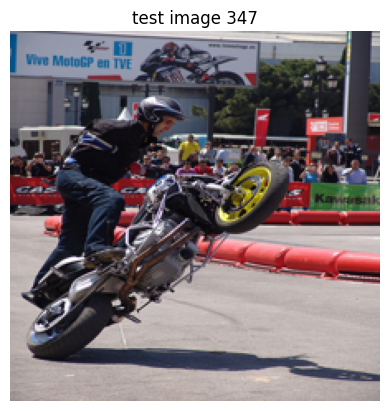

caption: a man doing tricks on a motorcycle


In [3]:
test_ds = load_dataset("jxie/flickr8k", split="test")

def img_of(i, size=(224, 224)):
    return test_ds[i]["image"].convert("RGB").resize(size)

# 확인용 샘플 이미지 + 첫 번째 caption
sample_img = img_of(SHOW_IDX)
sample_caption = test_ds[SHOW_IDX]["caption_0"]

plt.imshow(sample_img); plt.axis("off")
plt.title("test image %d" % SHOW_IDX)
plt.show()
print("caption:", sample_caption)


### 🧠 2. 고정된 CLIP Vision Encoder에서 이미지 feature 뽑기

> 📖 **논문 근거** — LLaVA는 CLIP ViT를 **고정(frozen)** 한 채 시각 feature만 뽑아 씁니다.

> 저희도 CLIP vision encoder를 얼려서 feature `Z_v` 만 얻습니다. (여기서는 768차원)


In [4]:
clip = CLIPModel.from_pretrained(CLIP_CKPT).to(device).eval()
proc = CLIPProcessor.from_pretrained(CLIP_CKPT)

@torch.no_grad()
def encode_image_patches(pil_img):
    """CLIP vision encoder로 이미지의 패치별 시각 feature를 뽑습니다.
    반환: [num_patches, 768]  (프로젝션 전 raw 시각 feature = Z_v)"""
    inputs = proc(images=pil_img, return_tensors="pt").to(device)
    vision_out = clip.vision_model(**inputs)          # frozen ViT
    # last_hidden_state: [1, num_patches+1, 768] (0번은 CLS 토큰)
    patches = vision_out.last_hidden_state[0, 1:, :]  # CLS 제외한 패치 토큰
    return patches.cpu()

Z_v = encode_image_patches(sample_img)
print("Z_v shape:", Z_v.shape, " <- (패치 개수, 768)  아직 LLM이 못 알아듣는 '비전 언어'")


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Z_v shape: torch.Size([49, 768])  <- (패치 개수, 768)  아직 LLM이 못 알아듣는 '비전 언어'


### 🔧 3. Projection — 시각 feature를 LLM 임베딩 차원으로 정렬

> 📖 **논문 근거** — LLaVA §3. 학습 가능한 **선형 사영 W** 하나로
> 시각 feature `Z_v` (768차원)를 LLM 단어 임베딩 공간 `H_v` (4096차원)로 옮깁니다.
> Cross-Attention도 Q-Former도 아닌 **선형 층 하나** 라는 점이 핵심입니다.


In [5]:
class Projection(nn.Module):
    """LLaVA의 connector: 시각 feature -> LLM 임베딩 차원 (선형 사영 하나)"""
    def __init__(self, d_in=CLIP_HIDDEN, d_out=LLM_HIDDEN):
        super().__init__()
        # ===== TODO 1 =====
        # 힌트: d_in(768) 차원을 d_out(4096) 차원으로 보내는 nn.Linear 하나를 만드세요.
        self.proj = nn.Linear(d_in, d_out)   # TODO
        # ==================

    def forward(self, z_v):
        # ===== TODO 2 =====
        # 힌트: 위에서 만든 self.proj 에 z_v 를 통과시켜 H_v 를 반환하세요.
        H_v = self.proj(z_v)         # TODO
        # ==================
        return H_v

torch.manual_seed(MY_SEED)
projection = Projection()

H_v = projection(Z_v)
print("Z_v shape:", tuple(Z_v.shape), " ->  H_v shape:", tuple(H_v.shape))
assert H_v.shape[-1] == LLM_HIDDEN, "H_v의 마지막 차원이 LLM 임베딩 차원(4096)이어야 합니다!"
print("통과 ✅  이제 H_v 는 텍스트 토큰과 같은 차원 -> LLM 입력에 나란히 놓을 수 있습니다.")


Z_v shape: (49, 768)  ->  H_v shape: (49, 4096)
통과 ✅  이제 H_v 는 텍스트 토큰과 같은 차원 -> LLM 입력에 나란히 놓을 수 있습니다.


### 🧩 4. 이미지 토큰을 텍스트 토큰 사이에 삽입

> 📖 **논문 근거** — LLaVA Figure 1. `<image>` 자리에 이미지 토큰 `H_v` 를 끼워 넣어
> 텍스트 토큰 `H_q` 와 **하나의 입력 시퀀스**로 이어붙입니다(concat).

아래는 "USER: `<image>` What is in the photo? ASSISTANT:" 처럼
텍스트 사이에 이미지 자리(`<image>`)가 있는 상황을 단순화한 것입니다.


텍스트 토큰 임베딩은 예시로 무작위 생성합니다(실제로는 LLM의 임베딩 층에서 나옵니다).


In [6]:
# 텍스트 토큰 임베딩 (예시): "앞부분 3토큰" <image> "뒷부분 4토큰"
# 실제로는 LLM의 embed_tokens 층이 만들지만, 여기서는 무작위로 대체합니다.
torch.manual_seed(MY_SEED)
text_before = torch.randn(3, LLM_HIDDEN)   # <image> 앞 텍스트 토큰 3개
text_after  = torch.randn(4, LLM_HIDDEN)   # <image> 뒤 텍스트 토큰 4개

def build_input_sequence(text_before, image_tokens, text_after):
    """텍스트 토큰 사이의 <image> 자리에 이미지 토큰을 끼워 하나의 시퀀스로 합칩니다."""
    # ===== TODO 3 =====
    # 힌트: torch.cat([...], dim=0) 으로 (앞 텍스트) + (이미지 토큰) + (뒤 텍스트) 순서로 이어붙이세요.
    seq = torch.cat([text_before, image_tokens, text_after], dim=0)   # TODO
    # ==================
    return seq

seq = build_input_sequence(text_before, H_v, text_after)
print("앞 텍스트:", tuple(text_before.shape))
print("이미지 토큰:", tuple(H_v.shape))
print("뒤 텍스트:", tuple(text_after.shape))
print("합쳐진 입력 시퀀스:", tuple(seq.shape))
expected = text_before.shape[0] + H_v.shape[0] + text_after.shape[0]
assert seq.shape == (expected, LLM_HIDDEN), "시퀀스 길이/차원이 맞지 않습니다!"
print("통과 ✅  이미지가 '가짜 단어 토큰'처럼 텍스트 사이에 들어갔습니다. 이제 LLM이 통째로 읽습니다.")


앞 텍스트: (3, 4096)
이미지 토큰: (49, 4096)
뒤 텍스트: (4, 4096)
합쳐진 입력 시퀀스: (56, 4096)
통과 ✅  이미지가 '가짜 단어 토큰'처럼 텍스트 사이에 들어갔습니다. 이제 LLM이 통째로 읽습니다.


### 📝 서술형 문제 1

위 3~4장의 결과(shape 출력)를 인용해서 답하세요.

1. 텍스트 토큰(`text_before`, `text_after`)은 projection을 거치지 않았는데도 이미지 토큰 `H_v` 와
   **그냥 이어붙일(concat) 수 있었습니다.** 두 종류 토큰의 shape를 인용하고, 이것이 가능했던 이유를 설명하세요.
2. 발표에서 "projection `W` 는 이미지에만 붙고 텍스트에는 붙지 않는다"고 했습니다.
   `Z_v`(768)와 `H_v`(4096), 그리고 텍스트 토큰(4096)의 차원을 근거로,
   **왜 이미지에만 W가 필요한지** 설명하세요. (LLM 입장에서 어느 쪽이 '모국어'인지 언급)

**✍️ 답변:**

1. `text_before`는 `[3, 4096]`, `text_after`는 `[4, 4096]`이고 projection을 거친 이미지 토큰 `H_v`는 `[49, 4096]`이다. 셋을 이어붙인 결과가 `[56, 4096]`으로 나왔다(3 + 49 + 4 = 56).

   `torch.cat(..., dim=0)`은 이어붙이는 축(0번, 토큰 개수)만 달라도 되고 **나머지 축은 전부 같아야** 한다. 세 텐서 모두 마지막 차원이 4096으로 일치했기 때문에 토큰 개수만 더해지면서 하나의 시퀀스가 됐다. 만약 projection 전의 `Z_v`(`[49, 768]`)를 그대로 붙이려 했다면 마지막 차원이 768과 4096으로 달라 바로 에러가 났을 것이다.

   그래서 projection이 한 일을 한 줄로 말하면, 이미지를 **텍스트 토큰과 "같은 모양의 물건"으로 만들어 준 것**이다. 이어붙이고 나면 LLM 입장에서는 56개가 전부 똑같은 4096차원 벡터일 뿐이고, 어느 것이 원래 이미지였는지 구분하지 않는다. 이미지가 "가짜 단어 토큰"처럼 문장 안에 들어갔다는 표현이 이 뜻이다.

2. 차원만 놓고 보면 이미지 쪽은 `Z_v` 768차원, 텍스트 쪽은 4096차원이라 애초에 숫자가 맞지 않는다. 그런데 **왜 텍스트를 768로 줄이지 않고 이미지를 4096으로 늘리는가**가 핵심이라고 생각했다.

   LLM 입장에서 4096차원 단어 임베딩 공간은 **모국어**다. Vicuna 같은 모델은 그 공간에서 방대한 텍스트로 사전학습을 마쳤고, 어떤 방향이 무슨 의미인지에 대한 규칙이 이미 그 안에 다 들어 있다. 반대로 `Z_v`의 768차원 공간은 CLIP이 이미지 쪽 과제를 풀면서 자기 사정에 맞게 만든 **외국어**다. 두 공간은 차원 수뿐 아니라 축이 뜻하는 바도 서로 무관하다.

   그래서 번역은 외국어 쪽이 해야 한다. 텍스트를 768로 끌어내리면 LLM이 지금까지 쌓아 온 언어 능력을 쓸 수 없는 공간으로 데려가는 셈이라, 멀쩡한 쪽을 망가뜨리는 일이 된다. 이미지를 4096으로 올리면 LLM은 평소 하던 대로 자기 공간에서 추론하면 되고, 바뀌는 건 "새로 들어온 토큰 49개"뿐이다.

   실제로 LLaVA에서 CLIP ViT는 freeze되어 있고 LLM도 1단계에서는 고정이며, **학습되는 것은 projection `W` 하나뿐**이다. 양쪽 다 건드리지 않고 사이에 번역기만 끼운 구조이고, 그래서 Flamingo의 Gated Cross-Attention이나 BLIP-2의 Q-Former 같은 장치 없이 선형 층 하나로 충분했다는 점이 이 논문의 주장이다.

### 🔁 6. Cross-Attention 방향 — Multimodal-CoT vs Latent Diffusion

발표에서 같은 Cross-Attention이 두 모델에서 **방향(Q/K·V)이 반대**라고 배웠습니다.
- **Multimodal-CoT**: Q = 텍스트, K·V = 이미지  → 텍스트가 이미지를 참조 (이해·추론)
- **Latent Diffusion**: Q = 이미지, K·V = 텍스트 → 이미지가 텍스트를 참조 (생성)

아래 단순화한 cross-attention 함수를 완성하고, 두 방향을 직접 비교합니다.


In [7]:
def cross_attention(Q, K, V):
    """표준 (single-head) cross-attention.
    Q: [n_q, d], K: [n_k, d], V: [n_k, d] -> 출력 [n_q, d]"""
    d = Q.shape[-1]
    # ===== TODO 4 =====
    # 힌트 1: 점수 = Q @ K.T / sqrt(d)
    # 힌트 2: 가중치 = softmax(점수, dim=-1)
    # 힌트 3: 출력 = 가중치 @ V
    scores  = Q @ K.T / math.sqrt(d)   # TODO
    weights = F.softmax(scores, dim=-1)   # TODO
    out     = weights @ V   # TODO
    # ==================
    return out, weights

# 아주 단순한 예시: 텍스트 단어 2개, 이미지 패치 3개 (d=4)
text_tokens  = torch.tensor([[1.,0,1,0],
                             [0,1.,0,1]])          # "cat", "sky"
image_tokens = torch.tensor([[1.,0,1,0],           # 패치0: cat과 비슷
                             [0,1.,0,1],            # 패치1: sky와 비슷
                             [.5,.5,0,0]])          # 패치2: 중간

# (A) Multimodal-CoT 방향: 텍스트가 Query, 이미지가 K·V
outA, wA = cross_attention(Q=text_tokens, K=image_tokens, V=image_tokens)
# (B) Latent Diffusion 방향: 이미지가 Query, 텍스트가 K·V
outB, wB = cross_attention(Q=image_tokens, K=text_tokens, V=text_tokens)

print("[A] MM-CoT (Q=텍스트, K·V=이미지)  가중치 shape:", tuple(wA.shape), " <- 행=텍스트 단어, 열=이미지 패치")
print(wA.round(decimals=2))
print()
print("[B] LDM  (Q=이미지, K·V=텍스트)   가중치 shape:", tuple(wB.shape), " <- 행=이미지 패치, 열=텍스트 단어")
print(wB.round(decimals=2))


[A] MM-CoT (Q=텍스트, K·V=이미지)  가중치 shape: (2, 3)  <- 행=텍스트 단어, 열=이미지 패치
tensor([[0.5400, 0.2000, 0.2600],
        [0.2000, 0.5400, 0.2600]])

[B] LDM  (Q=이미지, K·V=텍스트)   가중치 shape: (3, 2)  <- 행=이미지 패치, 열=텍스트 단어
tensor([[0.7300, 0.2700],
        [0.2700, 0.7300],
        [0.5000, 0.5000]])


### 📝 서술형 문제 2

위 6장의 두 attention 가중치 행렬(`wA`, `wB`)의 **shape를 각각 인용**해서 답하세요.

1. `wA`(MM-CoT)와 `wB`(LDM)의 shape가 서로 다릅니다. 각 행렬에서 **행(row)이 무엇을 의미하고
   열(column)이 무엇을 의미하는지** 쓰고, 왜 shape가 달라지는지 설명하세요.
2. "누가 Query가 되는가"는 그 모델이 **무엇을 만들어내려 하는가(이해/추론 vs 생성)** 와 연결됩니다.
   MM-CoT과 LDM 각각에서 Query가 텍스트/이미지인 이유를, 각 모델의 목적과 연결해 설명하세요.

**✍️ 답변:**

1. `wA`는 `(2, 3)`, `wB`는 `(3, 2)`로 서로 전치된 모양이다.

   `wA`는 행이 텍스트 단어 2개(cat, sky), 열이 이미지 패치 3개다. 출력값은

   ```
   [[0.54, 0.20, 0.26],
    [0.20, 0.54, 0.26]]
   ```

   으로, 첫 행(cat)은 패치0에 0.54를, 둘째 행(sky)은 패치1에 0.54를 주었다. 각 단어가 자기와 닮은 패치를 가장 많이 본 것이다.

   `wB`는 행이 이미지 패치 3개, 열이 텍스트 단어 2개다.

   ```
   [[0.73, 0.27],
    [0.27, 0.73],
    [0.50, 0.50]]
   ```

   패치0은 cat을 0.73, 패치1은 sky를 0.73으로 봤고, 어느 쪽과도 애매했던 패치2는 0.50 / 0.50으로 갈렸다.

   shape가 달라지는 이유는 attention의 출력 길이가 **Query의 개수**로 정해지기 때문이다. `softmax(QKᵀ/√d)`에서 Q가 `[n_q, d]`, K가 `[n_k, d]`이면 가중치는 항상 `[n_q, n_k]`가 된다. MM-CoT는 텍스트가 Q라서 `(단어 수, 패치 수)`, LDM은 이미지가 Q라서 `(패치 수, 단어 수)`다. 같은 수식인데 무엇을 Q 자리에 놓느냐만으로 행렬이 통째로 뒤집힌다.

   그리고 softmax가 걸리는 축이 마지막 차원이라는 점도 중요하다. 두 행렬 모두 **각 행의 합이 1**이다. `wA`에서는 "한 단어가 패치들에 나눠 준 주의"의 합이 1이고, `wB`에서는 "한 패치가 단어들에 나눠 준 주의"의 합이 1이다. 즉 누가 Q인지가 **무엇을 기준으로 배분 경쟁이 벌어지는지**까지 바꾼다.

2. 두 모델이 최종적으로 **무엇을 출력해야 하는가**가 Query를 정한다고 이해했다. Attention의 출력은 Query와 개수가 같으므로, Q 자리에는 그 모델이 갱신해서 내보내야 할 쪽이 와야 한다.

   **Multimodal-CoT**는 근거(rationale)와 정답을 **텍스트로** 내놓는 모델이다. 출력이 텍스트이니 갱신 대상도 텍스트 표현이어야 하고, 그래서 텍스트가 Q다. 각 단어가 "내 의미를 더 분명히 하려면 이미지의 어느 부분을 봐야 하나"를 묻고 이미지에서 근거를 당겨온다. `wA`의 cat이 패치0을 0.54로 본 것이 그 동작이다. 이미지는 참조되는 자료(K·V)일 뿐 그 자체가 출력으로 나가지 않는다.

   **Latent Diffusion**은 **이미지를** 내놓는 모델이다. 매 denoising 스텝에서 갱신해야 하는 건 latent의 각 위치이므로 이미지가 Q이고, 텍스트는 "무엇을 그릴지" 알려 주는 조건으로 K·V에 들어간다. 각 패치가 "나는 프롬프트의 어느 단어를 그려야 하나"를 묻는 구조다. `wB`에서 패치0이 cat을 0.73으로 선택한 것이 그 장면이고, 패치별로 다른 단어를 고를 수 있기 때문에 "왼쪽엔 고양이, 오른쪽엔 하늘" 같은 공간 배치가 가능해진다.

   정리하면 **이해·추론은 텍스트가 이미지를 읽어 가는 방향, 생성은 이미지가 텍스트를 받아 가는 방향**이다. 수식은 똑같고 Q/K·V 배치만 뒤집혔을 뿐인데, 그 하나로 모델의 성격이 갈린다는 점이 인상적이었다. 패치2가 0.50 / 0.50으로 갈린 것도 의미가 있어 보였는데, 조건이 애매한 영역은 생성에서도 어느 쪽으로도 확실히 가지 못한다는 뜻으로 읽었다.

### 📝 서술형 문제 3

발표에서 "Cross-Attention은 멀티모달 생성 모델의 **조종간**" 이라고 했습니다.

**Latent Diffusion에서 Cross-Attention으로 텍스트 조건을 넣지 않는다면**, "고양이를 그려줘"라는 요청에
모델은 무엇을 생성하게 될까요? 그리고 그 이유를 6장의 (B) 방향(이미지가 텍스트를 참조)과 연결해 설명하세요.

**✍️ 답변:**

**학습 데이터 분포에서 나올 법한 아무 이미지나 생성한다.** 고양이가 나올 수도 있지만 그건 학습 데이터에 고양이가 섞여 있어서 우연히 걸린 것이지, 요청을 들어서가 아니다. 프롬프트를 "고양이를 그려줘"로 쓰든 아무 말도 안 쓰든 결과가 달라지지 않는다.

이유는 (B) 방향의 구조를 보면 분명하다. LDM에서 Q는 이미지 패치, K·V는 텍스트였고, `wB`에서 패치0이 cat에 0.73의 가중치를 준 것은 **그 패치가 "나는 cat을 그려야 한다"는 정보를 텍스트에서 당겨온 장면**이다. Cross-Attention을 빼면 K·V 자리가 비어 이 경로 자체가 사라진다. 패치 입장에서는 참조할 조건이 없으니 자기 주변 latent만 보고 "그럴듯한 무언가"로 수렴할 뿐, 무엇을 향해 갈지를 알 방법이 없다.

여기서 중요한 건 **망가지는 것이 품질이 아니라 제어**라는 점이다. U-Net이 배운 "이 얼룩에서 노이즈가 어디인가"는 그대로 남아 있으므로 이미지는 여전히 선명하고 자연스럽게 나온다. 다만 그게 내가 원한 이미지일 이유가 없어진다. 조건부 생성이 무조건부 생성(unconditional)으로 떨어지는 것이고, 내용을 정할 수단은 초기 노이즈 하나뿐이라 원하는 그림이 나올 때까지 시드를 바꿔 가며 뽑는 수밖에 없다.

덧붙여 classifier-free guidance도 같이 쓸 수 없게 된다. CFG는 조건부 예측과 무조건부 예측의 차이를 증폭하는 방식인데, 조건부 경로가 없으면 뺄 대상이 없기 때문이다. `guidance_scale`로 프롬프트 반영 강도를 조절하는 것 자체가 불가능해진다.

"조종간"이라는 비유가 이 지점에서 잘 맞는다고 느꼈다. 조종간을 떼어 낸 차가 고장 난 것은 아니고 엔진도 잘 돌지만, 어디로 갈지를 내가 정할 수 없을 뿐이다. 이전 주차 과제에서 조건 없는 MNIST DDPM을 돌렸을 때 숫자는 나오는데 어떤 숫자가 나올지 지정할 수 없었던 것이 정확히 같은 상황이었다.

# 🔍 Part B. ImageBind 관찰

Part A에서 만든 것은 이미지-텍스트 **두 모달**의 연결이었습니다.
ImageBind는 이 아이디어를 여러 모달로 확장하되, **모든 쌍을 학습하지 않고 "이미지와의 쌍"만** 학습합니다.
그 결과 **직접 학습하지 않은 모달 쌍도 가까워지는** emergent alignment가 나타납니다.

여기서는 오디오·깊이 센서 대신, 우리가 접근 가능한 **사전학습 CLIP의 이미지·텍스트 공간**을 이용해
"이미지를 허브로 삼으면 왜 학습 안 한 쌍도 가까워지는가"를 숫자로 확인합니다.


### 📦 8. 사전학습 CLIP으로 이미지 허브 정렬 재현

> 📖 **논문 근거** — ImageBind §3. 각 모달을 **이미지와** 정렬하면, 이미지가 공통 기준점(허브)이 됩니다.

시나리오: 같은 대상('개')에 대한 서로 다른 두 텍스트 표현 A, B가 있다고 합시다.
둘 다 **개 이미지와 각각 정렬**되어 있다면(=이미지 허브), A와 B를 직접 비교한 적이 없어도 가까울까요?


In [8]:
@torch.no_grad()
def clip_image_embed(pil_img):
    inputs = proc(images=pil_img, return_tensors="pt").to(device)
    e = clip.get_image_features(**inputs)[0]
    return F.normalize(e, dim=-1).cpu()

@torch.no_grad()
def clip_text_embed(text):
    inputs = proc(text=[text], return_tensors="pt", padding=True).to(device)
    e = clip.get_text_features(**inputs)[0]
    return F.normalize(e, dim=-1).cpu()

def cos(a, b):
    return float(torch.dot(a, b))

# 개가 있는 이미지 하나를 test set에서 찾기: caption에 'dog'가 있는 첫 이미지
dog_idx = None
for i in range(len(test_ds)):
    if "dog" in test_ds[i]["caption_0"].lower():
        dog_idx = i; break
print("개 이미지 index:", dog_idx, "| caption:", test_ds[dog_idx]["caption_0"])

img_dog   = clip_image_embed(test_ds[dog_idx]["image"].convert("RGB"))   # 허브(이미지)
text_A    = clip_text_embed("a photo of a dog")        # 표현 A
text_B    = clip_text_embed("a puppy playing outside") # 표현 B (개를 다르게 표현)
text_far  = clip_text_embed("a red sports car")        # 무관한 표현

print("\n[이미지 허브와의 정렬]")
print("img_dog ↔ text_A(dog)   :", round(cos(img_dog, text_A), 3))
print("img_dog ↔ text_B(puppy) :", round(cos(img_dog, text_B), 3))
print("img_dog ↔ text_far(car) :", round(cos(img_dog, text_far), 3))


개 이미지 index: 0 | caption: The dogs are in the snow in front of a fence .

[이미지 허브와의 정렬]
img_dog ↔ text_A(dog)   : 0.255
img_dog ↔ text_B(puppy) : 0.253
img_dog ↔ text_far(car) : 0.17


### 📊 9. emergent alignment 측정

이제 **이미지를 거치지 않고 텍스트끼리 직접** 비교합니다.
A와 B는 서로 학습·비교된 적 없지만, 둘 다 개 이미지(허브)와 가깝다면 서로도 가까울 것으로 기대됩니다.


In [9]:
# ===== TODO 5 =====
# 힌트: 위에서 만든 cos() 함수로 텍스트-텍스트 유사도를 직접 구하세요.
sim_A_B   = cos(text_A, text_B)   # TODO: text_A 와 text_B 의 코사인 유사도
sim_A_far = cos(text_A, text_far)   # TODO: text_A 와 text_far 의 코사인 유사도
# ==================

print("text_A(dog) ↔ text_B(puppy) :", round(sim_A_B, 3), " <- 개끼리(허브 공유)")
print("text_A(dog) ↔ text_far(car) :", round(sim_A_far, 3), " <- 무관")
print()
if sim_A_B > sim_A_far:
    print("✅ 이미지 허브를 공유한 표현끼리 더 가깝다 -> emergent alignment 의 직관")


text_A(dog) ↔ text_B(puppy) : 0.836  <- 개끼리(허브 공유)
text_A(dog) ↔ text_far(car) : 0.72  <- 무관

✅ 이미지 허브를 공유한 표현끼리 더 가깝다 -> emergent alignment 의 직관


### 📝 서술형 문제 4

8~9장의 숫자를 **모두 인용**해서 답하세요.

1. `img_dog ↔ text_A`, `img_dog ↔ text_B` (8장)와 `text_A ↔ text_B` (9장)를 함께 인용해서,
   "두 표현이 각각 이미지(허브)와 가까웠다"는 사실과 "두 표현이 서로 가까웠다"는 사실을 연결해 설명하세요.
2. 발표의 ImageBind는 (이미지, 오디오)와 (이미지, 텍스트)만 학습해도 (오디오, 텍스트)가 정렬됐습니다.
   이 노트북 실험이 그 현상과 **어떻게 닮았고 어디가 다른지** 한 가지씩 쓰세요.
   (힌트: 우리는 진짜 오디오 대신 무엇으로 대체했나?)

**✍️ 답변:**

1. 출력값은 이랬다.

   - `img_dog ↔ text_A(dog)` = **0.255**
   - `img_dog ↔ text_B(puppy)` = **0.253**
   - `img_dog ↔ text_far(car)` = **0.170**
   - `text_A ↔ text_B` = **0.836**
   - `text_A ↔ text_far` = **0.720**

   먼저 허브 쪽을 보면, 개를 가리키는 두 표현 A("a photo of a dog")와 B("a puppy playing outside")는 개 이미지와 각각 0.255, 0.253으로 거의 같은 거리에 있었다. 무관한 표현인 car는 0.170으로 0.08 정도 낮았다. 두 표현이 같은 이미지를 기준점으로 비슷한 위치에 놓여 있다는 뜻이다.

   그다음 이미지를 거치지 않고 텍스트끼리 직접 비교했더니 A와 B가 0.836으로, A와 car의 0.720보다 0.116 높게 나왔다.

   여기서 중요한 건 CLIP이 **A와 B를 서로 비교하도록 학습한 적이 없다**는 점이다. CLIP의 InfoNCE는 (이미지, 캡션) 쌍만 보고 손실을 계산하며, 캡션끼리 가깝게 만들라는 항은 어디에도 없다. 그런데도 둘이 더 가까운 것은, 각자 같은 이미지 쪽으로 끌려가는 과정에서 **서로에게도 딸려 끌려갔기** 때문이다. 공통 기준점과의 거리가 비슷한 두 점은 자기들끼리도 멀 수 없다. 이게 ImageBind가 말하는 허브(hub)의 역할이고, 모든 쌍을 일일이 맞추지 않아도 기준 하나만 공유하면 나머지 관계가 따라온다는 근거다.

   다만 숫자를 그대로 믿기보다 **차이를 봐야 한다**는 것도 같이 느꼈다. 0.836이 높아 보이지만 무관한 car와도 0.720이나 나왔다. CLIP 텍스트 임베딩은 서로 다른 문장끼리도 기본적으로 꽤 높은 값이 나오는 편이라, 절대값이 아니라 **0.836 대 0.720이라는 간격**이 정렬의 증거다. 이미지-텍스트 쪽 값(0.255, 0.253)이 0.3도 안 되는데 retrieval은 잘 된다는 점도 같은 맥락인데, 모달이 다르면 중심 자체가 떨어져 있어서(modality gap) 절대값이 낮게 깔리기 때문이다. 결국 두 경우 모두 중요한 건 순위와 간격이지 숫자의 크기가 아니었다.

2. **닮은 점.** 직접 학습하지 않은 쌍이 가까워졌다는 구조가 같다. ImageBind는 (이미지, 오디오)와 (이미지, 텍스트)만 학습했는데 (오디오, 텍스트)가 정렬됐고, 이 실험은 (이미지, 캡션) 쌍만 학습한 CLIP에서 한 번도 맞춰 본 적 없는 (텍스트 A, 텍스트 B)가 0.836으로 가까웠다. 둘 다 이미지가 공통 기준점이 되어 학습 신호가 닿지 않은 곳까지 정렬이 번져 나간 emergent alignment다.

   **다른 점.** 우리는 **진짜 다른 모달을 쓰지 않았다.** 오디오나 깊이 센서 대신 같은 텍스트 인코더에서 나온 문장 두 개를 "서로 다른 표현"으로 삼았을 뿐이다. 그래서 A와 B는 애초에 같은 인코더, 같은 공간에 있었고 차원도 의미 축도 이미 공유된 상태였다. 반면 ImageBind의 오디오와 텍스트는 인코더 구조도 다르고 출력 공간도 따로 만들어진다. 건너야 할 간격의 크기가 전혀 다르다.

   그래서 이 실험은 emergent alignment의 **직관을 보여 주는 축소판**이지 그 자체를 재현한 것은 아니라고 생각한다. ImageBind가 놀라운 지점은 "같은 인코더가 만든 두 문장이 가깝다"가 아니라 "한 번도 짝지어 본 적 없는 **다른 종류의 센서 신호끼리** 가깝다"는 쪽이고, 그건 이 노트북으로는 확인할 수 없다. 덧붙이면 우리는 개 이미지 한 장(index 0, "The dogs are in the snow in front of a fence.")을 허브로 썼지만 ImageBind는 대규모 쌍 데이터로 정렬한 결과라, 일반화의 범위도 비교하기 어렵다.

#### 📚 참고 자료

**Part A**
- LLaVA: [Visual Instruction Tuning](https://arxiv.org/abs/2304.08485) (Liu et al., 2023) · [코드](https://github.com/haotian-liu/LLaVA)
- Multimodal-CoT: [Multimodal Chain-of-Thought Reasoning in Language Models](https://arxiv.org/abs/2302.00923) (Zhang et al., 2024)
- Latent Diffusion: [High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/abs/2112.10752) (Rombach et al., 2022)

**Part B**
- ImageBind: [One Embedding Space To Bind Them All](https://arxiv.org/abs/2305.05665) (Girdhar et al., 2023) · [코드](https://github.com/facebookresearch/ImageBind)

**더 읽어보기**
- Show-o: [One Single Transformer to Unify Multimodal Understanding and Generation](https://arxiv.org/abs/2408.12528) (ICLR 2025)
